<a href="https://colab.research.google.com/github/alimoorreza/CS181-fall26-notes/blob/main/day08_popular_cnn3_vgg16_dissection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS181: Computer Vision, Fall 2026

Tuesday, September 15, 2026

📆 [Course Schedule](https://analytics.drake.edu/~reza/teaching/cs181_fall26/cs181_schedule.html) | 📜 [Syllabus](https://analytics.drake.edu/~reza/teaching/cs181_fall26/cs181_syllabus_fall26.pdf)


In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


##**Utility functions**
- Load the mapping between the **class indices and class names** for the 1,000 ImageNet categories.
- Display the **top-5 or top-10 predicted classes** from the 1,000 ImageNet categories.


In [2]:
import torch
import torch.nn as nn
import torchvision
from torchvision import models, transforms, datasets

import sys
import os
import scipy.io

import json
import PIL
import numpy as np
import matplotlib.pyplot as plt

import requests
url = "https://analytics.drake.edu/~reza/teaching/cs181_fall26/datasets/imagenet_1000_classes.json"

response = requests.get(url)
response.raise_for_status()
label_map = response.json()
print(label_map)

def display_prediction(output_prob, label_map, how_many=10):
    print(f"label map: {label_map}")
    '''
    topk          = torch.topk(output_prob, k=how_many)
    topk_prob     = topk.values[0]
    topk_indices  = topk.indices[0]
    '''

    topk            = torch.topk(output_prob, k=how_many, dim=1)
    topk_prob       = topk.values[0]
    topk_indices    = topk.indices[0]


    if device == 'cuda':
        topk_indices  = topk_indices.data.cpu().numpy()
    else:
        topk_indices  = topk_indices.data.numpy()

    print(f"top{how_many}_classes are as follow: \n{topk_indices}")
    labels        = "{:75s}".format("predicted label")
    prob          = "{}".format("probability")
    print("\n{:75s}".format("--------------------------------------------------------------------------------------\n"), labels, prob,"\n{:75s}".format("--------------------------------------------------------------------------------------"))

    for i in range(how_many):
        labels  = label_map[str(topk_indices[i])]
        labels  = "{:75s}".format(labels)
        prob    = "{:.4f}".format(float(topk_prob[i]))
        print(labels, prob)

    print("{:75s}".format("--------------------------------------------------------------------------------------"))


def get_imagenet_mean_std_normalized():
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    return mean, std


{'0': 'tench, Tinca tinca', '1': 'goldfish, Carassius auratus', '2': 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', '3': 'tiger shark, Galeocerdo cuvieri', '4': 'hammerhead, hammerhead shark', '5': 'electric ray, crampfish, numbfish, torpedo', '6': 'stingray', '7': 'cock', '8': 'hen', '9': 'ostrich, Struthio camelus', '10': 'brambling, Fringilla montifringilla', '11': 'goldfinch, Carduelis carduelis', '12': 'house finch, linnet, Carpodacus mexicanus', '13': 'junco, snowbird', '14': 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', '15': 'robin, American robin, Turdus migratorius', '16': 'bulbul', '17': 'jay', '18': 'magpie', '19': 'chickadee', '20': 'water ouzel, dipper', '21': 'kite', '22': 'bald eagle, American eagle, Haliaeetus leucocephalus', '23': 'vulture', '24': 'great grey owl, great gray owl, Strix nebulosa', '25': 'European fire salamander, Salamandra salamandra', '26': 'common newt, Triturus vulgaris', '27': 'eft', '28': '

# **Creating VGGNet network architecture**
> ## **Loading model's pretrained weights from PyTorch library**

In [29]:
# You can give any name to your new network, e.g., VGGNet.
# You should load the pretrained VGGNet model from torchvision.models.
# This model was trained on over a million real-world images from ImageNet.

class VGGNet(nn.Module):

    def __init__(self, num_classes, pretrained=True):

        super(VGGNet, self).__init__()

        # download PyTorch's own implementation of VGG model trained on ImageNet dataset
        net = models.vgg16(pretrained=True)

        # retained weightes for convolutional, pooling, linear layers from VGG-16
        self.features   = net.features
        self.avgpool    = net.avgpool
        self.classifier = net.classifier

        # IMPORTANT: "If you need to fine-tune this network for your own dataset,
        # the simplest modification is to replace the last layer in self.classifier with
        # the updated VGGNet has the desired number of output classes: 'num_classes'
        # self.classifier[-1] = nn.Linear(4096, num_classes) # only this last layer's weights will be trained from scratch


    def forward(self, x):

        print("VGG (forward pass): shape of input: ", x.shape)
        x = self.features(x)
        print("VGG (forward pass): output shape (self.features): ", x.shape)
        x = self.avgpool(x)
        print("VGG (forward pass): output shape (self.avgpool): ", x.shape)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        print("VGG (forward pass): output shape (self.classifier): ", x.shape)
        return x



In [30]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device = ", device)
number_of_classes = 1000
model             = VGGNet(number_of_classes)
model.to(device)


device =  cuda


VGGNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilatio

# **Doing single forward pass on vggnet using a sample image**

### **Run the pretrained model on a random image to test its classification ability**
> I have uploaded the images of `cat,` `dog,` and `bike` to Blackboard.

> You can download those images and upload them to your workspace. Alternatively, you can download random images of a `cat,` `dog,` or `any other class of your choice` and test them using vggnet.


[width, height] of the image: [1024, 683]


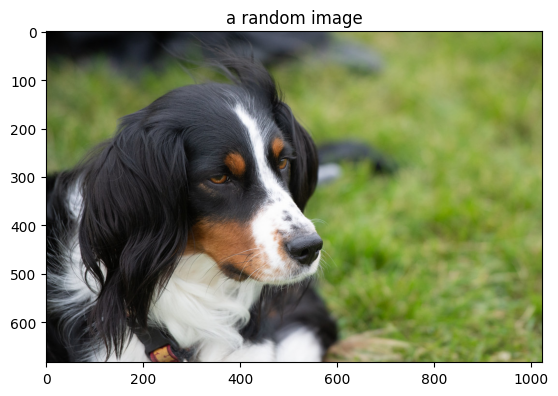

In [24]:
TEST_IMAGE_DIR  = '/content/drive/MyDrive/cs181_fall26/module_3_classification/images/'
image_name_list = ['random_dog1.jpg',
                   'random_dog2.jpg',
                   'random_cat1.jpg',
                   'random_cat2.jpg',
                   'random_bike1.jpg'
                   ]

img_index       = 0
img_name        = TEST_IMAGE_DIR + '/' + image_name_list[img_index]

# read the image and display
img             = PIL.Image.open(img_name)
print(f"[width, height] of the image: [{img.size[0]}, {img.size[1]}]")
plt.imshow(img)
plt.title("a random image")
plt.show()


##**Transform the image by resizing + normalizing it with ImageNet mean**
- CNN architectures such as AlexNet, VGGNet, and ResNet has been pre-trained using the ImageNet dataset.
- You need to normalize each image with the given mean and standard deviation before doing the forward-pass on these networks.
- You can compose resize and normalize operations together using `torchvision.transform` operation



In [9]:
imagenet_mean, imagenet_std  = get_imagenet_mean_std_normalized()
print(f"ImageNet: mean: {imagenet_mean}, std: {imagenet_std}")


TEST_IMAGE_SIZE_W   = 227
TEST_IMAGE_SIZE_H   = 227

# CNN architectures such as AlexNet, VGGNet, and ResNet has been pre-trained using the ImageNet dataset.
# You need to normalize each image with the given mean and standard deviation before doing the forward-pass on these networks.
transform = transforms.Compose([
    transforms.Resize((TEST_IMAGE_SIZE_W, TEST_IMAGE_SIZE_H)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std) # ImageNet: mean (R, G, B) and standard deviation (R, G, B)
])

img_transformed          = transform(img).unsqueeze(0).to(device)
print(f"Convert the image into PyTorch tensor after normalization: ...")
print(f"image tensor shape: {img_transformed.shape}") # [HOW_MANY_TENSORS, CHANNEL_SIZE, HEIGHT, WIDTH]
print(f"{"HOW_MANY_TENSORS:":<20} {img_transformed.shape[0]}")
print(f"{"CHANNEL_SIZE:":<20} {img_transformed.shape[1]}")
print(f"{"HEIGHT_SIZE:":<20} {img_transformed.shape[2]}")
print(f"{"WIDTH_SIZE:":<20} {img_transformed.shape[3]}")
print(f"Summary: [how_many, channel, height, width] of the image tensor: {img_transformed.shape[0]}x{img_transformed.shape[1]}x{img_transformed.shape[2]}x{img_transformed.shape[3]}")



ImageNet: mean: [0.485, 0.456, 0.406], std: [0.229, 0.224, 0.225]
Convert the image into PyTorch tensor after normalization: ...
image tensor shape: torch.Size([1, 3, 227, 227])
HOW_MANY_TENSORS:    1
CHANNEL_SIZE:        3
HEIGHT_SIZE:         227
WIDTH_SIZE:          227
Summary: [how_many, channel, height, width] of the image tensor: 1x3x227x227


### **Show the transformed image (for verification)**

> PLEASE NOTE: Each pixel value has **changed after normalization**. There is now a stark contrast in the pixel values.

shape: torch.Size([227, 227, 3])


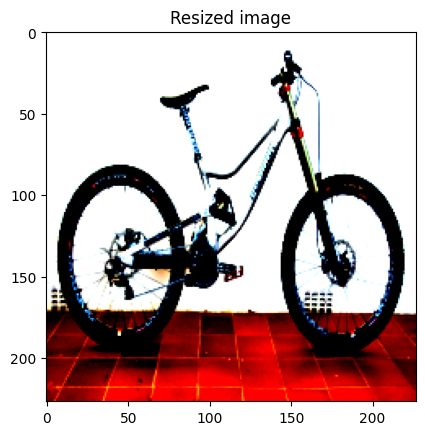

In [11]:
transformed_back_img = img_transformed.squeeze(0).cpu()
transformed_back_img = transformed_back_img.permute(1, 2, 0)
print(f"shape: {transformed_back_img.shape}")
plt.imshow(transformed_back_img.data)
plt.title("Resized image")
plt.show()


## **Perform a forward pass of the input volume through your VGGNet.**


In [12]:
# forward pass the transformed image through your CNN network
model.eval()       # put the model in evaluation mode to get consistent output
raw_output = model(img_transformed)
output_probability = torch.softmax( raw_output, dim=1 )


VGG (forward pass): shape of input:  torch.Size([1, 3, 227, 227])
VGG (forward pass): output shape (self.features):  torch.Size([1, 512, 7, 7])
VGG (forward pass): output shape (self.avgpool):  torch.Size([1, 512, 7, 7])
VGG (forward pass): output shape (self.classifier):  torch.Size([1, 1000])


In [13]:
tmp = output_probability.cpu().detach().numpy()
print(f"Sum of all predicted probabilities: {np.sum(tmp)}")
print(f"Probability of class-0: {tmp[0][0]}")
print(f"Probability of class-1: {tmp[0][1]}")

Sum of all predicted probabilities: 1.0
Probability of class-0: 1.486038292419778e-09
Probability of class-1: 7.1309771421113055e-09


### **Identifying the predicted label from the list of 1,000 predefined ImageNet classes.**
- Our forward pass of the input volume through AlexNet will produce a prediction corresponding to one of these 1,000 classes. We need to map the predicted class index to the appropriate ImageNet class name.**

label map: {'0': 'tench, Tinca tinca', '1': 'goldfish, Carassius auratus', '2': 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', '3': 'tiger shark, Galeocerdo cuvieri', '4': 'hammerhead, hammerhead shark', '5': 'electric ray, crampfish, numbfish, torpedo', '6': 'stingray', '7': 'cock', '8': 'hen', '9': 'ostrich, Struthio camelus', '10': 'brambling, Fringilla montifringilla', '11': 'goldfinch, Carduelis carduelis', '12': 'house finch, linnet, Carpodacus mexicanus', '13': 'junco, snowbird', '14': 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', '15': 'robin, American robin, Turdus migratorius', '16': 'bulbul', '17': 'jay', '18': 'magpie', '19': 'chickadee', '20': 'water ouzel, dipper', '21': 'kite', '22': 'bald eagle, American eagle, Haliaeetus leucocephalus', '23': 'vulture', '24': 'great grey owl, great gray owl, Strix nebulosa', '25': 'European fire salamander, Salamandra salamandra', '26': 'common newt, Triturus vulgaris', '27': 'ef

/tmp/ipykernel_583/2976424446.py:49: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  prob    = "{:.4f}".format(float(topk_prob[i]))


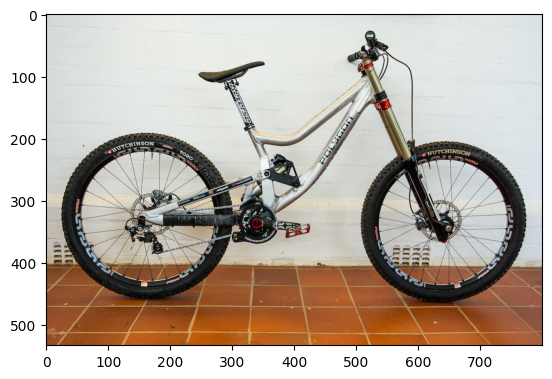

In [14]:
# results after the completion of the forward pass through VGGNet
#print(f"raw probability: {output_prob}")
display_prediction(output_probability, label_map, how_many=10)
plt.imshow(img)

##**To summarize**
- **you need to do the following steps to pass an input through a pretrained model like VGGNet and observe the classification label with probabilities as follows:**

input image.shape=torch.Size([1, 3, 227, 227])
VGG (forward pass): shape of input:  torch.Size([1, 3, 227, 227])
VGG (forward pass): output shape (self.features):  torch.Size([1, 512, 7, 7])
VGG (forward pass): output shape (self.avgpool):  torch.Size([1, 512, 7, 7])
VGG (forward pass): output shape (self.classifier):  torch.Size([1, 1000])
label map: {'0': 'tench, Tinca tinca', '1': 'goldfish, Carassius auratus', '2': 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', '3': 'tiger shark, Galeocerdo cuvieri', '4': 'hammerhead, hammerhead shark', '5': 'electric ray, crampfish, numbfish, torpedo', '6': 'stingray', '7': 'cock', '8': 'hen', '9': 'ostrich, Struthio camelus', '10': 'brambling, Fringilla montifringilla', '11': 'goldfinch, Carduelis carduelis', '12': 'house finch, linnet, Carpodacus mexicanus', '13': 'junco, snowbird', '14': 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', '15': 'robin, American robin, Turdus migratorius', '16':

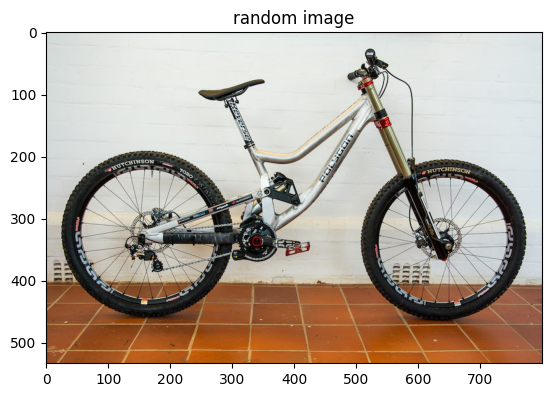

In [43]:
# ------------------------Make a class the load pretrained weights of the CNN------------------------------------------------
num_of_classes = 1000
model = VGGNet(num_of_classes)
model.to(device)

# ------------------------Read an image using PIL------------------------------------------------
img_index       = 4
img_name        = TEST_IMAGE_DIR + '/' + image_name_list[img_index]
img = PIL.Image.open(img_name)
plt.imshow(img)
plt.title("random image")

# ------------------------Transform the image by resizing + normalizing -------------------------
imagenet_mean, imagenet_std = get_imagenet_mean_std_normalized()
my_transform = transforms.Compose(
    [ transforms.Resize( (227, 227) ),
      transforms.ToTensor(),
      transforms.Normalize(mean=imagenet_mean, std=imagenet_std)]
)
img_transformed = my_transform(img).unsqueeze(0).to(device)
print(f"input image.shape={img_transformed.shape}")

# ------------------------Apply forward pass through your CNN-----------------------------------------
model.eval()
raw_output = model(img_transformed)
output_prob = torch.softmax( raw_output, dim=1 )
display_prediction(output_prob, label_map, how_many=7)

#**Group task#1**
> ### **Task 1: Modify the VGGNet network architecture by updating the last layer's structure and replace the pretrained weights of the last layer with new random weights.**

In [44]:
import torch
import torch.nn as nn
from torchvision import models
import pdb

import PIL
from PIL import Image
import json
import torch
import torchvision
import torchvision.transforms as T

import sys
import matplotlib.pyplot as plt
import scipy.io
import os

from torchvision import transforms, datasets


class VGGNet(nn.Module):

    def __init__(self, num_classes, pretrained=True):

        super(VGGNet, self).__init__()

        # download PyTorch's own implementation of VGG model trained on ImageNet dataset
        net = models.vgg16(pretrained=True)

        # retained weightes for convolutional, pooling, linear layers from VGG-16
        self.features   = net.features
        self.avgpool    = net.avgpool
        self.classifier = net.classifier

        # -----------------------MODIFICATION-------------------------------------
        # IMPORTANT: If you need to fine-tune this network for your own dataset,
        # the simplest modification is to replace the last layer in self.classifier with
        # the updated VGGNet has the desired number of output classes: 'num_classes'
        self.classifier[-1] = nn.Linear(4096, num_classes) # only this last layer's weights will be trained from scratch
        # ------------------------------------------------------------------------


    def forward(self, x):

        print("shape of input: ", x.shape)
        x = self.features(x)
        print("output shape (self.features): ", x.shape)
        x = self.avgpool(x)
        print("output shape (self.avgpool): ", x.shape)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        print("output shape (self.classifier): ", x.shape)
        return x


> ### **Task 2: Run the pretrained model on a random image to test its classification ability**

> Essentially, repeat the experiment we did earlier.


In [ ]:
# your code
# ...
# ...
# ...

> ### **Task 3: Summarize your observations and discuss them with your group members.**

>> Do you notice anything unusual, or does everything seem normal?

>> Explain your reasoning.


##**your answer**

# ...
# ...
# ...

#**Group task#2 (optional)**
> ### **Change the network layout of VGGNet so that you could see the size of individual features after each intermediate layer**

> Define the network

In [46]:
import torch
import torch.nn as nn
import torchvision
from torchvision import models, transforms, datasets

import sys
import os
import scipy.io

import json
import PIL
import numpy as np
import matplotlib.pyplot as plt

import requests

class VGGNet(nn.Module):

    def __init__(self, num_classes, pretrained=True):

        super(VGGNet, self).__init__()

        net             = models.vgg16(pretrained=True)

        # further dissecting attribute: net.features
        # 1st conv2d layers
        self.conv1_1      = net.features[0]
        self.relu1_1      = net.features[1]
        self.conv1_2      = net.features[2]
        self.relu1_2      = net.features[3]
        self.maxpool1     = net.features[4]

        # 2nd conv2d layers
        self.conv2_1      = net.features[5]
        self.relu2_1      = net.features[6]
        self.conv2_2      = net.features[7]
        self.relu2_2      = net.features[8]
        self.maxpool2     = net.features[9]

        # 3rd conv2d layers
        self.conv3_1      = net.features[10]
        self.relu3_1      = net.features[11]
        self.conv3_2      = net.features[12]
        self.relu3_2      = net.features[13]
        self.conv3_3      = net.features[14]
        self.relu3_3      = net.features[15]
        self.maxpool3     = net.features[16]

        # 4th conv2d layers
        self.conv4_1      = net.features[17]
        self.relu4_1      = net.features[18]
        self.conv4_2      = net.features[19]
        self.relu4_2      = net.features[20]
        self.conv4_3      = net.features[21]
        self.relu4_3      = net.features[22]
        self.maxpool4     = net.features[23]

        # 5th conv2d layers
        self.conv5_1      = net.features[24]
        self.relu5_1      = net.features[25]
        self.conv5_2      = net.features[26]
        self.relu5_2      = net.features[27]
        self.conv5_3      = net.features[28]
        self.relu5_3      = net.features[29]
        self.maxpool5     = net.features[30]


        # adaptive average pooling
        '''
        (avgpool): AdaptiveAvgPool2d(output_size=(7, 7))
        '''
        self.avgpool    = net.avgpool


        # further dissecting attribute: net.classifier
        # fully connected layers sequentially placed towards the end
        self.fc6      = net.classifier[0] # or create a new layer if you want to learn from scratch: nn.Linear(512 * 7 * 7, 4096)
        self.relu6    = net.classifier[1] # or create a new layer: nn.ReLU(True)
        self.dropout1 = net.classifier[2] # or create a new layer: nn.Dropout()

        self.fc7      = net.classifier[3] # or create a new layer if you want to learn from scratch: nn.Linear(4096, 512)
        self.relu7    = net.classifier[4] # or create a new layer: nn.ReLU(True)
        self.dropout2 = net.classifier[5] # or create a new layer: nn.Dropout()

        self.fc8     = nn.Linear(4096, num_classes) # create a linear layer with a dense connection of 4096 x num_classess neurons


    def forward(self, x):

        print(f"[{x.shape[1:]}] INPUT")
        x = self.conv1_1(x)
        x = self.relu1_1(x)
        print(f"[{x.shape[1:]}] CONV1_1: 64 convolutional filters each with a shape=3x3, stride=1, pad=1")
        x = self.conv1_2(x)
        x = self.relu1_2(x)
        print(f"[{x.shape[1:]}] CONV1_2: 64 convolutional filters each with a shape=3x3, stride=1, pad=1")
        x = self.maxpool1(x)
        print(f"[{x.shape[1:]}] MAX POOL1: 2x2 max pooling filters with stride=2, pad=0")


        x = self.conv2_1(x)
        x = self.relu2_1(x)
        print(f"[{x.shape[1:]}] CONV2_1: 128 convolutional filters each with a shape=3x3, stride=1, pad=1")
        x = self.conv2_2(x)
        x = self.relu2_2(x)
        print(f"[{x.shape[1:]}] CONV2_2: 128 convolutional filters each with a shape=3x3, stride=1, pad=1")
        x = self.maxpool2(x)
        print(f"[{x.shape[1:]}] MAX POOL2: 2x2 max pooling filters with stride=2, pad=0")


        x = self.conv3_1(x)
        x = self.relu3_1(x)
        print(f"[{x.shape[1:]}] CONV3_1: 256 convolutional filters each with a shape=3x3, stride=1, pad=1")
        x = self.conv3_2(x)
        x = self.relu3_2(x)
        print(f"[{x.shape[1:]}] CONV3_2: 256 convolutional filters each with a shape=3x3, stride=1, pad=1")
        x = self.conv3_3(x)
        x = self.relu3_3(x)
        print(f"[{x.shape[1:]}] CONV3_3: 256 convolutional filters each with a shape=3x3, stride=1, pad=1")
        x = self.maxpool3(x)
        print(f"[{x.shape[1:]}] MAX POOL3: 2x2 max pooling filters with stride=2, pad=0")



        x = self.conv4_1(x)
        x = self.relu4_1(x)
        print(f"[{x.shape[1:]}] CONV4_1: 512 convolutional filters each with a shape=3x3, stride=1, pad=1")
        x = self.conv4_2(x)
        x = self.relu4_2(x)
        print(f"[{x.shape[1:]}] CONV4_2: 512 convolutional filters each with a shape=3x3, stride=1, pad=1")
        x = self.conv4_3(x)
        x = self.relu4_3(x)
        print(f"[{x.shape[1:]}] CONV4_3: 512 convolutional filters each with a shape=3x3, stride=1, pad=1")
        x = self.maxpool4(x)
        print(f"[{x.shape[1:]}] MAX POOL4: 2x2 max pooling filters with stride=2, pad=0")


        x = self.conv5_1(x)
        x = self.relu5_1(x)
        print(f"[{x.shape[1:]}] CONV5_1: 512 convolutional filters each with a shape=3x3, stride=1, pad=1")
        x = self.conv5_2(x)
        x = self.relu5_2(x)
        print(f"[{x.shape[1:]}] CONV5_2: 512 convolutional filters each with a shape=3x3, stride=1, pad=1")
        x = self.conv5_3(x)
        x = self.relu5_3(x)
        print(f"[{x.shape[1:]}] CONV5_3: 512 convolutional filters each with a shape=3x3, stride=1, pad=1")
        x = self.maxpool5(x)
        print(f"[{x.shape[1:]}] MAX POOL5: 2x2 max pooling filters with stride=2, pad=0")



        x = self.avgpool(x)
        print(f"[{x.shape[1:]}] AVG POOL: fixed output size [width x height] ")
        x = torch.flatten(x, 1)

        x = self.fc6(x)
        x = self.relu6(x)
        print(f"[{x.shape[1:]}] FC6: neurons")
        x = self.dropout1(x)

        x = self.fc7(x)
        x = self.relu7(x)
        print(f"[{x.shape[1:]}] FC7: neurons")
        x = self.dropout2(x)

        x = self.fc8(x)
        print(f"[{x.shape[1:]}] FC8: neurons")

        return x



> Do the forward pass through vggnet using an image

> Do you get the same correct results as before?
> If yes, why?
> If no, why not?

input image.shape=torch.Size([1, 3, 227, 227])
[torch.Size([3, 227, 227])] INPUT
[torch.Size([64, 227, 227])] CONV1_1: 64 convolutional filters each with a shape=3x3, stride=1, pad=1
[torch.Size([64, 227, 227])] CONV1_2: 64 convolutional filters each with a shape=3x3, stride=1, pad=1
[torch.Size([64, 113, 113])] MAX POOL1: 2x2 max pooling filters with stride=2, pad=0
[torch.Size([128, 113, 113])] CONV2_1: 128 convolutional filters each with a shape=3x3, stride=1, pad=1
[torch.Size([128, 113, 113])] CONV2_2: 128 convolutional filters each with a shape=3x3, stride=1, pad=1
[torch.Size([128, 56, 56])] MAX POOL2: 2x2 max pooling filters with stride=2, pad=0
[torch.Size([256, 56, 56])] CONV3_1: 256 convolutional filters each with a shape=3x3, stride=1, pad=1
[torch.Size([256, 56, 56])] CONV3_2: 256 convolutional filters each with a shape=3x3, stride=1, pad=1
[torch.Size([256, 56, 56])] CONV3_3: 256 convolutional filters each with a shape=3x3, stride=1, pad=1
[torch.Size([256, 28, 28])] MAX 

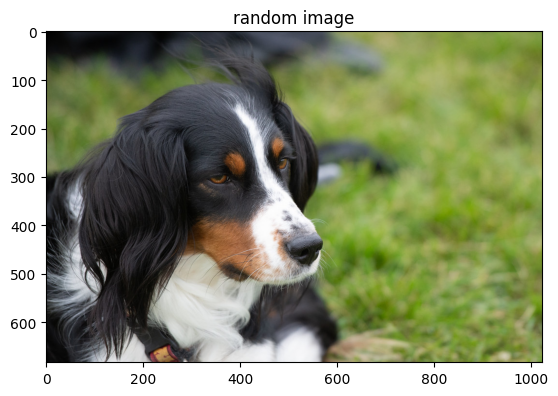

In [48]:
# ------------------------Make a class the load pretrained weights of the CNN------------------------------------------------
num_of_classes = 1000
model = VGGNet(num_of_classes)
model.to(device)

# ------------------------Read an image using PIL------------------------------------------------
img_index       = 0
img_name        = TEST_IMAGE_DIR + '/' + image_name_list[img_index]
img = PIL.Image.open(img_name)
plt.imshow(img)
plt.title("random image")

# ------------------------Transform the image by resizing + normalizing -------------------------
imagenet_mean, imagenet_std = get_imagenet_mean_std_normalized()
my_transform = transforms.Compose(
    [ transforms.Resize( (227, 227) ),
      transforms.ToTensor(),
      transforms.Normalize(mean=imagenet_mean, std=imagenet_std)]
)
img_transformed = my_transform(img).unsqueeze(0).to(device)
print(f"input image.shape={img_transformed.shape}")

# ------------------------Apply forward pass through your CNN-----------------------------------------
model.eval()
raw_output = model(img_transformed)
output_prob = torch.softmax( raw_output, dim=1 )
display_prediction(output_prob, label_map, how_many=7)